# Objective

This notebook evaluates financial stability using macroeconomic indicators obtained from the World Bank database. The analysis examines how inflation, unemployment, GDP growth, interest rates, and public debt influence financial stability and credit risk.

The notebook concludes with scenario-based stress testing to estimate the potential impact of adverse economic conditions on a banking portfolio.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [5]:
# Load World Bank Dataset
df = pd.read_csv(
    "world_bank_data_2025.csv"
)

df.head()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


In [6]:
# Dataset Overview
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3472
Columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   object 
 1   country_id                       3472 non-null   object 
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 1

# Available Economic Indicators
--Inflation (CPI %)
--GDP Growth (%)
--GDP per Capita
--Unemployment Rate
--Interest Rate
--Public Debt (% GDP)
--Government Revenue
--Government Expense

In [8]:
# Select India
india = df[
    df["country_name"] == "India"
].copy()

india.head()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
1424,India,in,2010,11.989390,1.675616e+12,1347.519391,7.652,-1.983859,10.526031,8.497585,-3.253484,16.505136,13.183597,10.388040,1.657661e+12,51.591910
1425,India,in,2011,8.911793,1.823052e+12,1445.461275,7.616,1.317981,8.733579,5.241316,-3.429285,14.489839,11.495996,10.177387,1.807021e+12,51.556554
1426,India,in,2012,9.478997,1.827638e+12,1429.321995,7.666,2.473520,7.934387,5.456388,-5.004890,16.166712,12.599873,10.836772,1.806177e+12,50.678031
1427,India,in,2013,10.017878,1.856722e+12,1432.843975,7.711,3.865993,6.186504,6.386106,-2.645667,16.638683,12.608993,11.001626,1.833601e+12,50.311827
1428,India,in,2014,6.665657,2.039126e+12,1553.883961,7.674,6.695176,3.331757,7.410228,-1.339509,14.803138,11.550621,9.984654,2.015014e+12,49.900925


In [9]:
# Time Period Covered
print(
    "Start Year:",
    india["year"].min()
)

print(
    "End Year:",
    india["year"].max()
)

Start Year: 2010
End Year: 2025


# GDP Growth Trend

--Economic growth is one of the strongest indicators of financial stability.

--Higher GDP growth generally supports stronger borrower repayment capacity and   lower default risk.

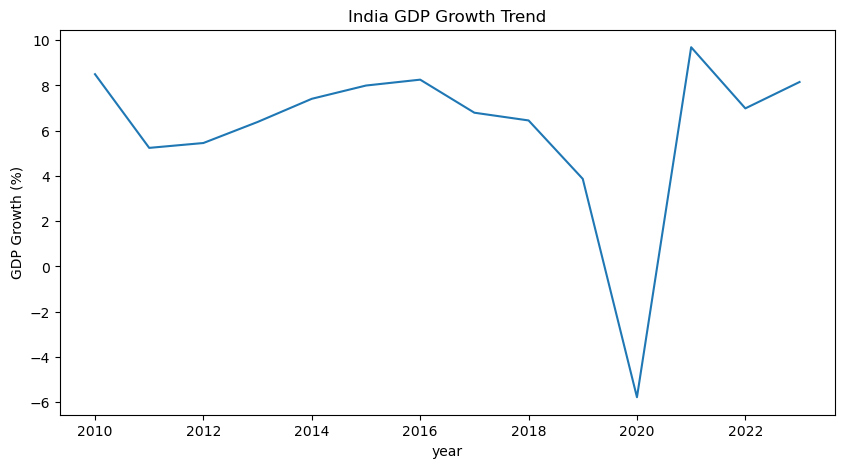

In [10]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=india,
    x="year",
    y="GDP Growth (% Annual)"
)

plt.title(
    "India GDP Growth Trend"
)

plt.ylabel(
    "GDP Growth (%)"
)

plt.show()

# Inflation Trend

Persistent inflation can reduce household purchasing power and increase repayment pressure.


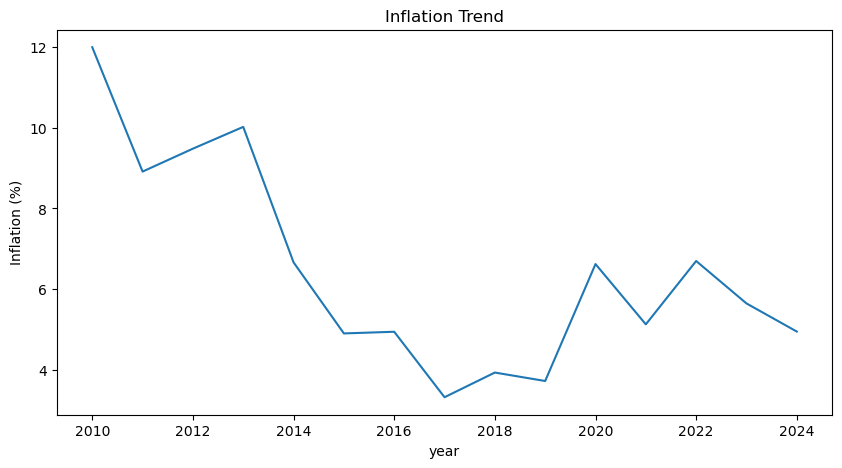

In [11]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=india,
    x="year",
    y="Inflation (CPI %)"
)

plt.title(
    "Inflation Trend"
)

plt.ylabel(
    "Inflation (%)"
)

plt.show()

# Unemployment Trend

Rising unemployment often leads to increased credit defaults because borrowers may experience income loss.

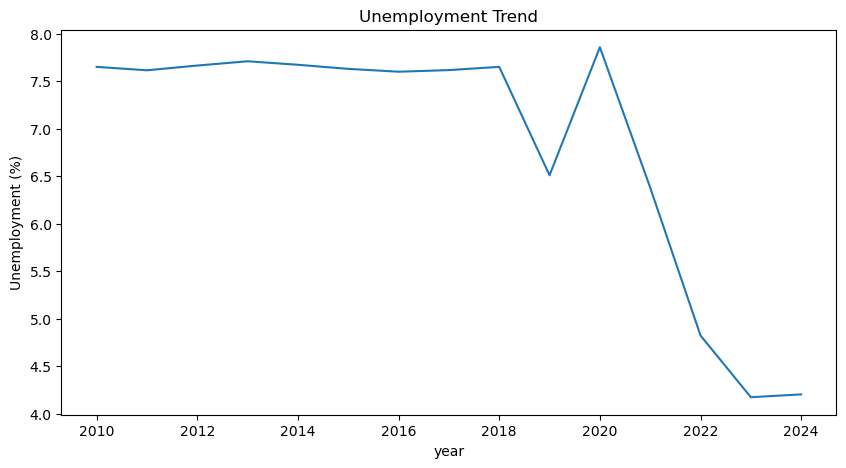

In [13]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=india,
    x="year",
    y="Unemployment Rate (%)"
)

plt.title(
    "Unemployment Trend"
)

plt.ylabel(
    "Unemployment (%)"
)

plt.show()

# Public Debt Trend

Increasing public debt may reduce fiscal flexibility during economic crises.

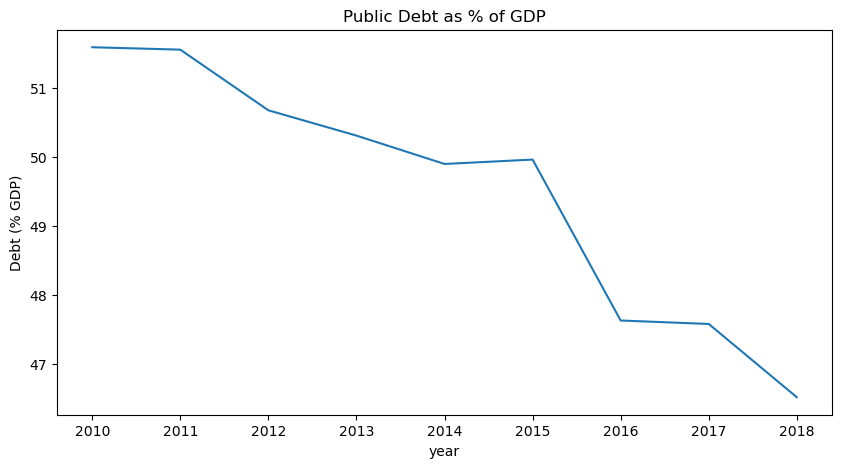

In [14]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=india,
    x="year",
    y="Public Debt (% of GDP)"
)

plt.title(
    "Public Debt as % of GDP"
)

plt.ylabel(
    "Debt (% GDP)"
)

plt.show()

# Correlation Analysis

Correlation analysis helps identify relationships among economic indicators affecting financial stability.


In [15]:
macro_cols = [

    "Inflation (CPI %)",

    "GDP Growth (% Annual)",

    "Unemployment Rate (%)",

    "Interest Rate (Real, %)",

    "Public Debt (% of GDP)"
]

corr_df = india[macro_cols]

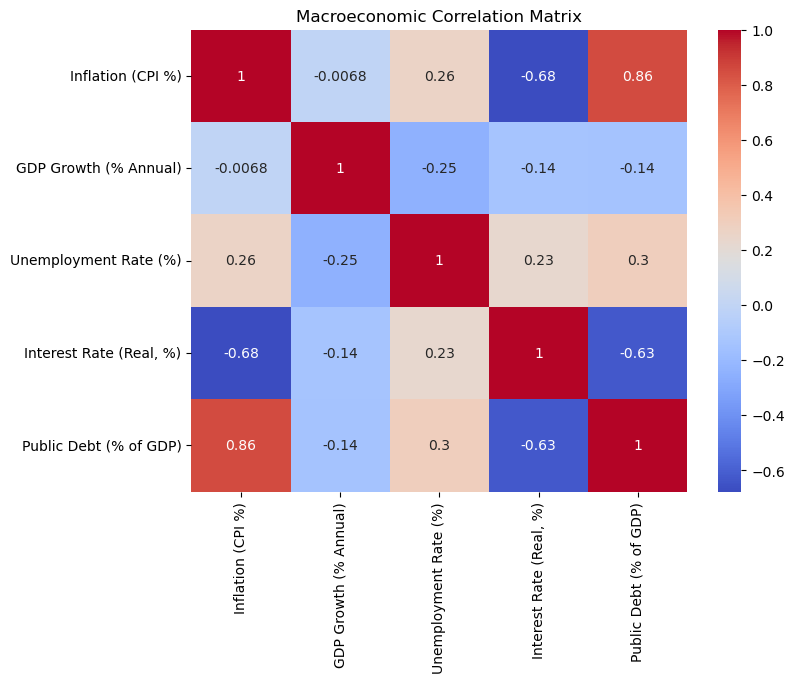

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Macroeconomic Correlation Matrix"
)

plt.show()

# Financial Stability Score

- Create a simple composite stability score.

- Higher GDP Growth improves stability.

- Higher Inflation, Unemployment, and Public Debt reduce stability.

In [18]:
india["Financial_Stability_Score"] = (

    india["GDP Growth (% Annual)"]

    - india["Inflation (CPI %)"]

    - india["Unemployment Rate (%)"]

    - (india["Public Debt (% of GDP)"] / 10)

)

# Financial Stability Trend

- Higher scores indicate relatively stronger macroeconomic conditions.

- Lower scores indicate increased economic vulnerability.

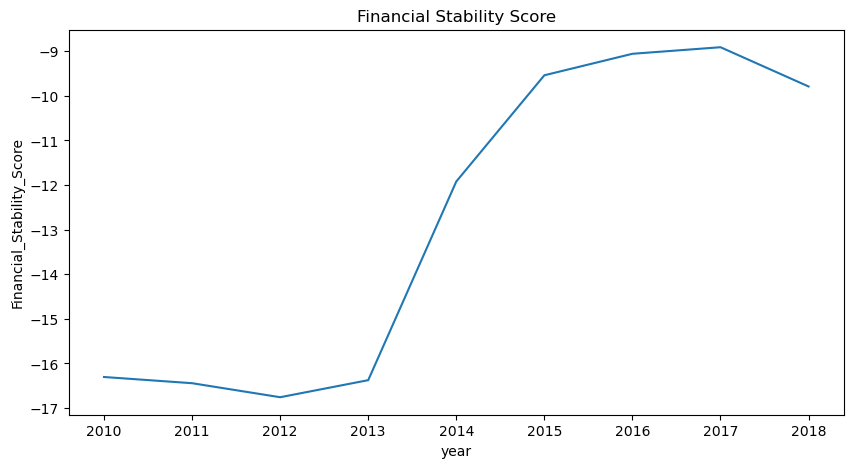

In [19]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=india,
    x="year",
    y="Financial_Stability_Score"
)

plt.title(
    "Financial Stability Score"
)

plt.show()

# Stress Testing
Baseline Portfolio Assumptions

In [23]:
LGD = 0.60

EAD = 1000000

In [21]:
# Economic Scenarios
scenarios = {

    "Normal":0.08,

    "Mild Recession":0.15,

    "Severe Crisis":0.25
}
# Expected Loss Function

def expected_loss(pd, lgd, ead):

    return pd * lgd * ead

In [24]:
# Scenario Analysis

results = []

for scenario,pd_value in scenarios.items():

    loss = expected_loss(
        pd_value,
        LGD,
        EAD
    )

    results.append([
        scenario,
        pd_value,
        loss
    ])

In [25]:
stress_df = pd.DataFrame(

    results,

    columns=[
        "Scenario",
        "Probability_of_Default",
        "Expected_Loss"
    ]
)

stress_df

,Scenario,Probability_of_Default,Expected_Loss
0,Normal,0.08,48000.0
1,Mild Recession,0.15,90000.0
2,Severe Crisis,0.25,150000.0


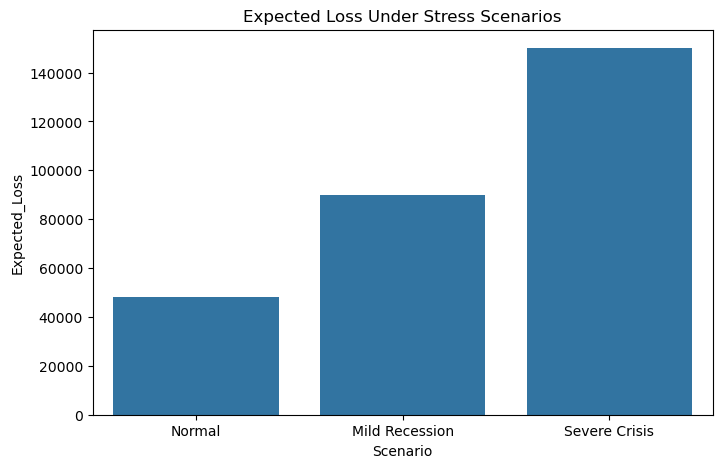

In [26]:
# Stress Testing Results

plt.figure(figsize=(8,5))

sns.barplot(
    data=stress_df,
    x="Scenario",
    y="Expected_Loss"
)

plt.title(
    "Expected Loss Under Stress Scenarios"
)

plt.show()

# Key Findings

- GDP growth and inflation have significant implications for financial stability.

- Economic downturns increase portfolio risk.

- Expected losses rise sharply during stress scenarios.

- Stress testing provides a useful framework for evaluating banking resilience.

- Combining borrower-level machine learning models with macroeconomic analysis produces a more comprehensive view of credit risk.


# Conclusion

- This notebook extended credit risk analysis beyond individual borrowers by incorporating macroeconomic indicators and stress testing techniques.

- The results demonstrate that adverse economic conditions can substantially increase expected losses and weaken financial stability, highlighting the importance of proactive risk management in the banking sector.